In [23]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/hunter0007/m1-data/M1_data.csv


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
df= pd.read_csv('/kaggle/input/datasets/hunter0007/m1-data/M1_data.csv')
df.head()

,trust_apple,interest_computers,age_computer,user_pcmac,appleproducts_count,familiarity_m1,f_batterylife,f_price,f_size,f_multitasking,...,f_neural,f_synergy,f_performanceloss,m1_consideration,m1_purchase,gender,age_group,income_group,status,domain
0,No,4,8,PC,0,No,5,4,3,4,...,2,1,1,1,Yes,Male,2,2,Student,Science
1,Yes,2,4,PC,1,No,5,5,5,3,...,2,2,4,2,No,Male,2,3,Employed,Finance
2,Yes,5,6,PC,0,No,3,4,2,4,...,2,2,2,4,Yes,Male,2,2,Student,IT & Technology
3,Yes,2,6,Apple,4,No,4,3,3,4,...,4,4,3,2,No,Female,2,2,Student,Arts & Culture
4,Yes,4,4,Apple,7,Yes,5,3,3,4,...,3,4,4,4,Yes,Male,5,7,Employed,Hospitality


In [26]:
df.shape

(133, 22)

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 133 entries, 0 to 132
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   trust_apple          133 non-null    object
 1   interest_computers   133 non-null    int64 
 2   age_computer         133 non-null    int64 
 3   user_pcmac           133 non-null    object
 4   appleproducts_count  133 non-null    int64 
 5   familiarity_m1       133 non-null    object
 6   f_batterylife        133 non-null    int64 
 7   f_price              133 non-null    int64 
 8   f_size               133 non-null    int64 
 9   f_multitasking       133 non-null    int64 
 10  f_noise              133 non-null    int64 
 11  f_performance        133 non-null    int64 
 12  f_neural             133 non-null    int64 
 13  f_synergy            133 non-null    int64 
 14  f_performanceloss    133 non-null    int64 
 15  m1_consideration     133 non-null    int64 
 16  m1_purch

In [28]:
df.describe()

,interest_computers,age_computer,appleproducts_count,f_batterylife,f_price,f_size,f_multitasking,f_noise,f_performance,f_neural,f_synergy,f_performanceloss,m1_consideration,age_group,income_group
count,133.00000,133.000000,133.000000,133.000000,133.000000,133.000000,133.000000,133.000000,133.000000,133.000000,133.000000,133.000000,133.000000,133.000000,133.000000
mean,3.81203,2.827068,2.609023,4.526316,3.872180,3.157895,4.120301,3.729323,4.398496,3.165414,3.466165,3.375940,3.609023,2.969925,2.969925
std,0.96256,2.444881,1.898303,0.723826,0.995547,1.166724,0.798081,1.129010,0.768113,1.142700,1.276530,1.125473,1.242155,1.898723,2.014868
min,2.00000,0.000000,0.000000,1.000000,1.000000,1.000000,2.000000,1.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,3.00000,1.000000,1.000000,4.000000,3.000000,2.000000,4.000000,3.000000,4.000000,2.000000,3.000000,3.000000,3.000000,2.000000,1.000000
50%,4.00000,3.000000,3.000000,5.000000,4.000000,3.000000,4.000000,4.000000,5.000000,3.000000,4.000000,4.000000,4.000000,2.000000,2.000000
75%,5.00000,5.000000,4.000000,5.000000,5.000000,4.000000,5.000000,5.000000,5.000000,4.000000,4.000000,4.000000,5.000000,3.000000,4.000000
max,5.00000,9.000000,8.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,10.000000,7.000000


In [29]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)

In [30]:
df.isnull().sum()

trust_apple            0
interest_computers     0
age_computer           0
user_pcmac             0
appleproducts_count    0
familiarity_m1         0
f_batterylife          0
f_price                0
f_size                 0
f_multitasking         0
f_noise                0
f_performance          0
f_neural               0
f_synergy              0
f_performanceloss      0
m1_consideration       0
m1_purchase            0
gender                 0
age_group              0
income_group           0
status                 0
domain                 0
dtype: int64

In [31]:
y = df['m1_purchase']
print(y.value_counts())

m1_purchase
Yes    82
No     43
Name: count, dtype: int64


In [32]:
print(df['user_pcmac'].value_counts())

user_pcmac
Apple    80
PC       43
Hp        1
Other     1
Name: count, dtype: int64


In [33]:
df['purchased'] = df['m1_purchase'].apply(lambda x: 1 if x== "Yes" else 0)
df['trust_apple'] = df['trust_apple'].apply(lambda x: 1 if x== "Yes" else 0)
df['user_pcmac'] = df['user_pcmac'].apply(lambda x: 1 if x== "Apple" else 0)
df['familiarity_m1'] = df['familiarity_m1'].apply(lambda x: 1 if x== "Yes" else 0)
df['gender'] = df['gender'].apply(lambda x: 1 if x== "Male" else 0)

In [34]:
df.head()

,trust_apple,interest_computers,age_computer,user_pcmac,appleproducts_count,familiarity_m1,f_batterylife,f_price,f_size,f_multitasking,...,f_synergy,f_performanceloss,m1_consideration,m1_purchase,gender,age_group,income_group,status,domain,purchased
0,0,4,8,0,0,0,5,4,3,4,...,1,1,1,Yes,1,2,2,Student,Science,1
1,1,2,4,0,1,0,5,5,5,3,...,2,4,2,No,1,2,3,Employed,Finance,0
2,1,5,6,0,0,0,3,4,2,4,...,2,2,4,Yes,1,2,2,Student,IT & Technology,1
3,1,2,6,1,4,0,4,3,3,4,...,4,3,2,No,0,2,2,Student,Arts & Culture,0
4,1,4,4,1,7,1,5,3,3,4,...,4,4,4,Yes,1,5,7,Employed,Hospitality,1


In [35]:
x= df.drop(columns=['status','domain','m1_purchase','purchased'])
y=df['purchased']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=42)

In [36]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

In [37]:
import numpy as np
np.exp(lr.coef_)

array([[2.13063388, 0.88976575, 0.75081804, 2.89346586, 0.94392244,
        1.08523391, 0.80884133, 0.88074953, 0.79119883, 1.89531965,
        0.9747578 , 0.56390907, 0.8162589 , 1.30481792, 0.7399426 ,
        2.28800842, 0.96590171, 0.75762305, 1.43802335]])

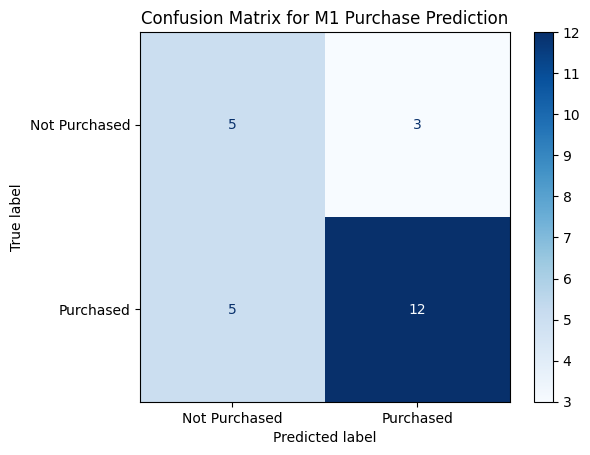

In [38]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Generate the matrix (standard order: True, then Pred)
cm = confusion_matrix(y_test, y_pred)

# 2. Plot it beautifully
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Purchased', 'Purchased'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for M1 Purchase Prediction")
plt.show()

In [39]:
from sklearn.metrics import classification_report

# This gives you Precision, Recall, and F1-score in one go
print(classification_report(y_test, y_pred, target_names=['Not Purchased', 'Purchased']))

               precision    recall  f1-score   support

Not Purchased       0.50      0.62      0.56         8
    Purchased       0.80      0.71      0.75        17

     accuracy                           0.68        25
    macro avg       0.65      0.67      0.65        25
 weighted avg       0.70      0.68      0.69        25



When it comes to predicting purchases:

* The model is correct 80% of the time. (precision)
* The model was able to capture 71% of the people who actually made the purchase. (recall)
* The F1 score is the balance, which is good.

When it comes to predicting not purchased:

* The model is correct 50% of the time. (not good)
* The model was right 62% of the overall not-purchased population.
* The balance, which is 56%, is also not good.
  
The model is too optimistic due to an imbalance in the dataset.

When it comes to predicting purchases:

The model is correct 80% of the time. (precision)
The model was able to capture 71% of the people who actually made the purchase. (recall)
The F1 score is the balance, which is good.
When it comes to predicting not purchased:

The model is correct 50% of the time. (not good)
The model was right 62% of the overall not-purchased population.
The balance, which is 56%, is also not good
The model is too optimistic due to an imbalance in the dataset.

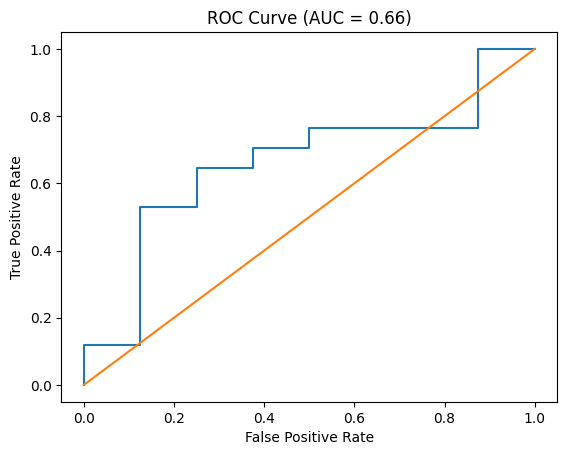

AUC Score: 0.6617647058823529


In [41]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Get probabilities for class 1
y_prob = lr.predict_proba(X_test)[:, 1]

# Compute ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Compute AUC
auc_score = roc_auc_score(y_test, y_prob)

# Plot
plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1])  # Diagonal reference line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve (AUC = {auc_score:.2f})")
plt.show()

print("AUC Score:", auc_score)

The model has moderate discriminative ability. 

It correctly ranks a randomly chosen positive instance higher than a negative one 66% of the time. 

It is better than random guessing but not strong enough for high-confidence decision-making without further improvement.